# Tarea 3 Algoritmos de Aprendizaje Supervisado #
## Dataset Arboles de Decisión – Red Wine Quality ##
### Jaime Daniel Cerón Rosales ###
### UNAD - 2025 ###

## OBJETIVOS ##
- Aplicar técnicas de clasificación basadas en árboles de decisión construir modelo predictivos que permitan estimar la calidad del vino.

- Determinar cuáles son los factores que más inciden en la calidad del vino con base a las clases de vino.

## DATOS ##
Los datos son obtenidos de https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data  El archivo en el cual esta la información es:  winequality-red con  extensión .cvs No se realiza ninguna modificación adicional.

##  DESARROLLO
A continuación se realizará las actividades propuestas para la entrega de la Tarea 3.

### 1. Exploración y Perfilamiento de datos

**Cargue de librerias y datos**

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
!pip install colorama

from sklearn.model_selection import train_test_split, KFold,GridSearchCV, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score,classification_report
from sklearn.tree import export_text
from colorama import init, Fore
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.tree import export_text


**Lectura de datos**

In [5]:
data_raw = pd.read_csv('/content/winequality-red.csv') # Ruta de acceso a los datos
data_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Dimensiones e información del DataFrame**

In [6]:
#Dimensión del DataFrame
data_raw.shape

(1599, 12)

In [7]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
data_raw.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
print(data_raw['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


**Datos ausentes y duplicados** Para el perfilamiento de datos se examina la calidad de los datos por medio de los valores faltantes y duplicados

In [10]:
data_raw.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [11]:
data_raw.duplicated().sum()

np.int64(240)

Explorando la distribucion de la variable objetivo "quality"

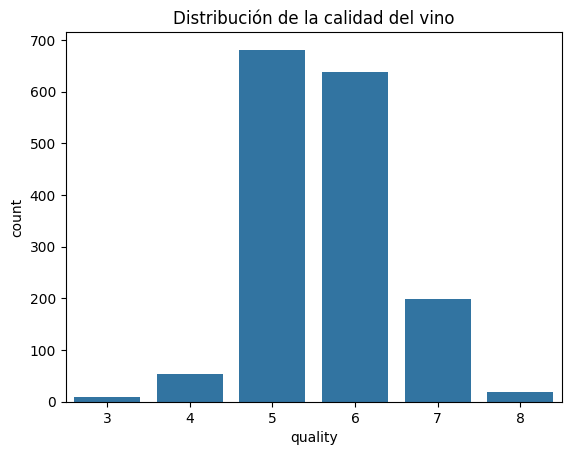

In [12]:
sns.countplot(x='quality', data=data_raw)
plt.title('Distribución de la calidad del vino')
plt.show()

Se puede observar que las clases de calidad van de 3 a 8. La mayoría de los vinos tienen calidad 5 o 6, y muy pocos tienen calidad 3 o 8. Lo cual nos indica que hay un desbalance en las clases

**Correlación de las variables** A continuación se realiza la Matriz de correlación de las variables, esto puede ayudar más adelante a seleccionar las variables más informativas.

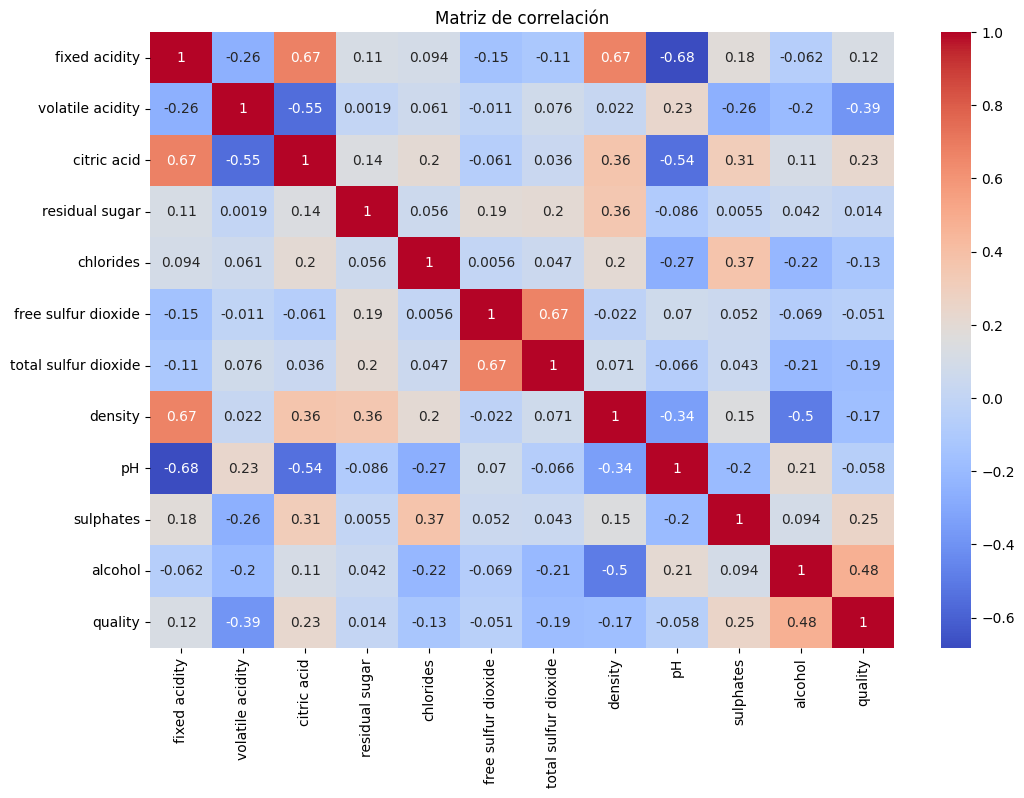

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(data_raw.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

Se puede observar que la variable Alcohol tiene una correlación positiva de alrededor de 0.48 con quality. Eso significa que en promedio, vinos con más alcohol tienden a tener mejor calidad.
Por otra parte volatile acidity tiene una correlación negativa moderada con quality (~-0.39), lo cual sugiere que niveles altos de acidez volátil suelen asociarse con menor calidad.

Variables como citric acid tiene una correlación positiva débil/moderada, density y pH tienen coeficientes cercanos a 0, es decir, no están claramente relacionados con la calidad del vino.

Finalmente fixed acidity y citric acid tienen una correlación entre sí superior a 0.5, indicando una relación interna es decir, son variables que se comportan de forma parecida.

**Posibles valores atípicos** Aunque los árboles de decisión manejan bien los outliers, es importante analizarlos en el caso que puedan llegar a afectar el modelo por lo que en este caso no sería crítico tratarlos, pero es importante tenerlos en cuenta.

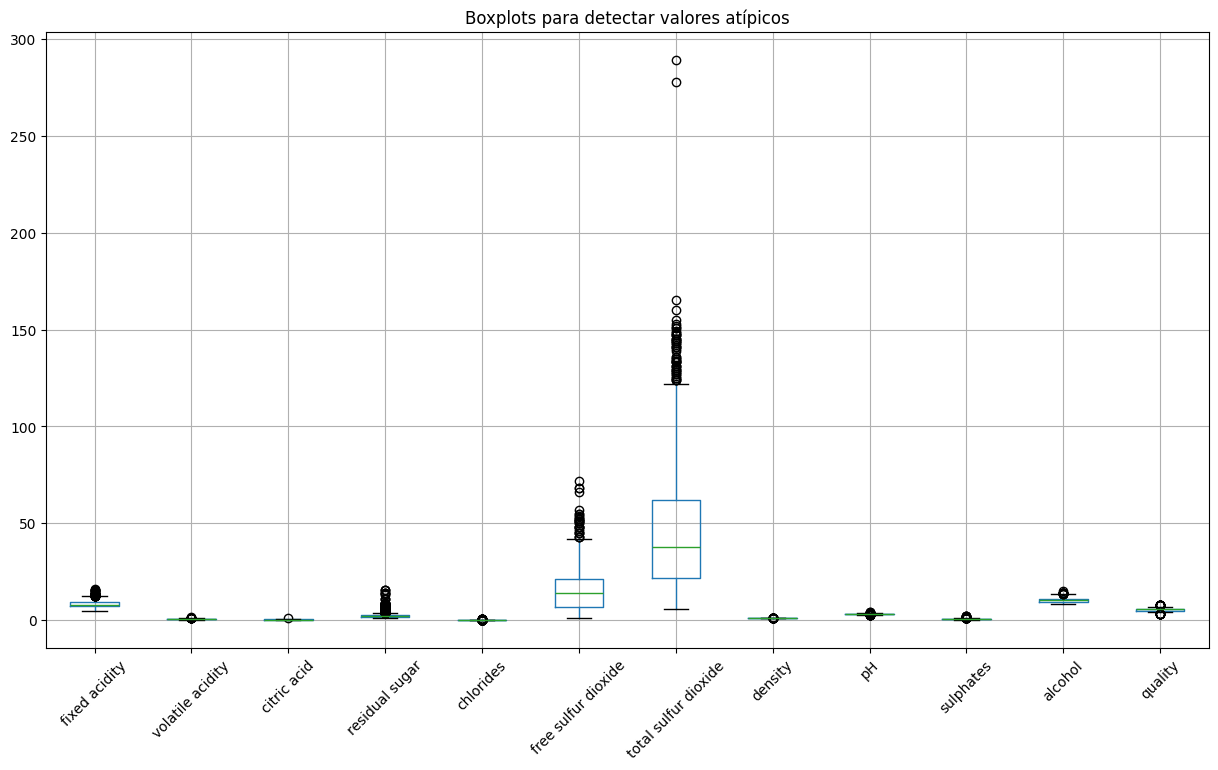

In [14]:
data_raw.boxplot(figsize=(15,8), rot=45)
plt.title("Boxplots para detectar valores atípicos")
plt.show()

Algunas variables como residual sugar, free sulfur dioxide y total sulfur dioxide tienen valores extremos. No son necesariamente errores

De esta exploración inicial se puede concluir que,No hay valores nulos y todas las variables son numéricas, Hay desbalance en la variable objetivo, que debemos considerar al modelar. la varialbe "alcohol" parece ser un predictor fuerte de la calidad.Existen outliers en algunas variables, pero dado que se usará árboles de decisión, no es estrictamente necesario tratarlos.
Algunas variables están correlacionadas entre sí, lo que podría influir en la selección de características.



## 2. Preparación de los datos

Durante el primer acercamiento a los datos, se ha identificado que no hay valores faltantes, por lo que no es necesario imputar o eliminar filas/columnas. Todos los datos son numéricos (float64 para las variables de entrada y int64 para la columna quality). Por tanto  no se requiere  codificación de variables categóricas.

La variable original quality tiene valores enteros entre 3 y 8, lo cual representa un problema de clasificación multiclase. Sin embargo, esta distribución está desbalanceada y muchas clases tienen pocas muestras, lo que dificulta el entrenamiento efectivo de modelos supervisados.

Según la documentación del dataset para facilitar el modelado y la interpretación, se transforma esta variable en una clasificación binaria, considerando como vino de buena calidad aquellos con una puntuación de 7 o más, y como no buenos los que tienen puntuaciones inferiores.



In [15]:
data = data_raw.copy()

**Creación de la variable binaria quality**

In [16]:
# 1 si calidad >= 7 (buen vino), 0 en otro caso
data['quality_binary'] = (data['quality'] >= 7).astype(int)

In [17]:
# Se elimina columnas que ya no se usarán
data = data.drop(['quality'], axis=1, errors='ignore')

Se verifica el dataset

In [18]:
print(data.head())
print(data['quality_binary'].value_counts())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality_binary  
0      9.4               0  
1      9.8               0  

## 3. Selección de características.

Se quiere identificar qué variables fisicoquímicas (como acidez, alcohol, etc.) son las más relevantes para predecir si un vino es "bueno" (quality_binary = 1).Anteriormente en el analisis inicial ya arrojó una idea de las variable que pueden influir .

Inicialmente se hará un grafico de correlación con la nueva variable quality_binary, posteriormente se hará Árbol de decisión simple con el objetivo de que el modelo per se elija qué variables son más importantes.

**Correlación con la variable objetivo**

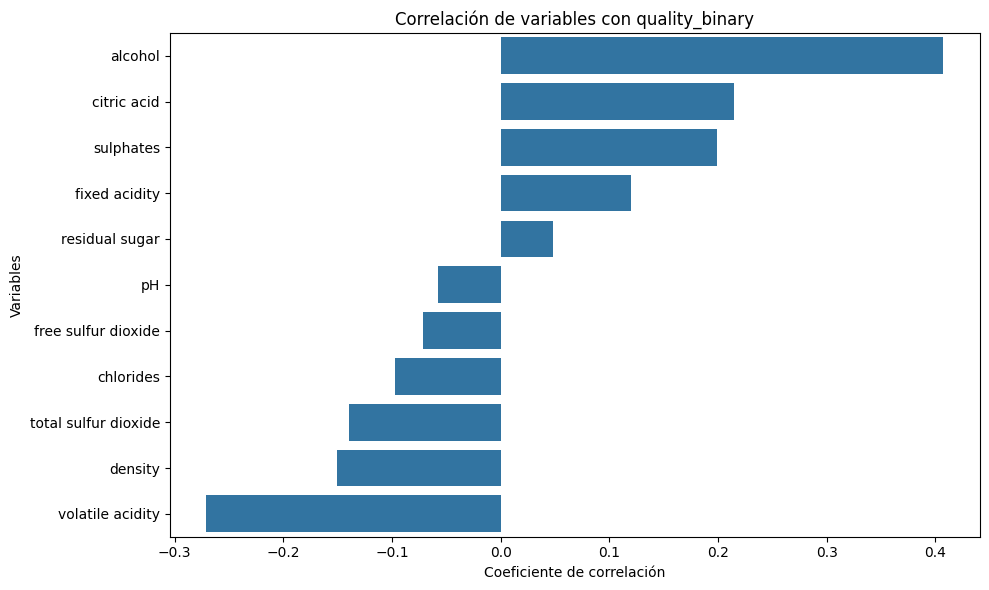

alcohol                 0.407315
citric acid             0.214716
sulphates               0.199485
fixed acidity           0.120061
residual sugar          0.047779
pH                     -0.057283
free sulfur dioxide    -0.071747
chlorides              -0.097308
total sulfur dioxide   -0.139517
density                -0.150460
volatile acidity       -0.270712
Name: quality_binary, dtype: float64


In [28]:
# Matriz de correlación
correlation_matrix = data.corr()

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(
    x=correlation_matrix['quality_binary'].drop('quality_binary').sort_values(ascending=False),
    y=correlation_matrix['quality_binary'].drop('quality_binary').sort_values(ascending=False).index
)
plt.title('Correlación de variables con quality_binary')
plt.xlabel('Coeficiente de correlación')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

print(correlation_matrix['quality_binary'].drop('quality_binary').sort_values(ascending=False))

**Árbol de decisión simple**

**Creación Variable X y Y**

In [21]:
X = data.drop(['quality_binary'], axis=1)
y = data['quality_binary']

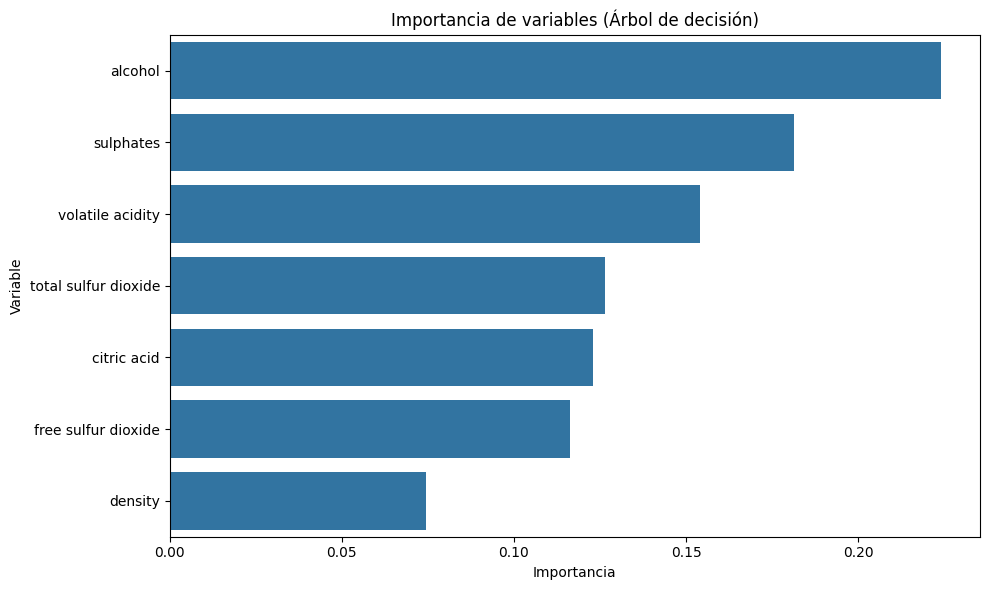

alcohol                 0.224180
sulphates               0.181415
volatile acidity        0.154166
total sulfur dioxide    0.126457
citric acid             0.122883
free sulfur dioxide     0.116331
density                 0.074568
dtype: float64 [0.22418022 0.18141475 0.1541658  0.12645673 0.11633145 0.12288347
 0.07456758]


In [54]:
# Entrenamiento de un árbol simple
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

# importancia de variables
importances = model.feature_importances_

# Visualización
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Importancia de variables (Árbol de decisión)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print(feature_importance, importances)

In [31]:
features = [
    'alcohol',
    'sulphates',
    'volatile acidity',
    'total sulfur dioxide',
    'free sulfur dioxide',
    'citric acid',
    'density'
]

Para entrenar el modelo, se seleccionaron las variables más relevantes en este caso 7 combinando dos enfoques complementarios: la correlación lineal con la variable objetivo (quality_binary) y la importancia de características calculada a partir de un árbol de decisión simple. Variables como alcohol, sulphates y volatile acidity demostraron tanto una alta correlación como una alta relevancia práctica en la construcción del árbol. Además, se incluyeron otras variables como total sulfur dioxide, free sulfur dioxide, citric acid y density, que, si bien no tienen la mayor correlación, aportaron significativamente en la capacidad del árbol para clasificar correctamente los vinos. Esta combinación busca balancear la interpretación estadística con el rendimiento predictivo real del modelo.

## 4. División en Train y test
Debido al desbalance de las clases, para tratar de mantener la proporción entre las clases se usará el 75% de los datos para entrenamiento y el 25% para prueba, adicionalmente se usará estratificación para garantizar que tanto el conjunto de entrenamiento como el de prueba tengan una distribución similar de vinos buenos y no bueno y una semilla random de 30

In [62]:
X = data[features]


# Variable objetivo
y = data['quality_binary']

# División estratificada en Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=30,
    stratify=y  # mantiene la proporción de clases
)

## 5. Entrenar el modelo con ajuste de hiperparámetros.
Para la busqueda de hiperparámetros se usa GridSearchCV




In [56]:

# Se define el clasificador base
modeldt = DecisionTreeClassifier(random_state=30)

Se define una grid para la busqueda de hiperparámetros se buscará entre los criterios de evaluación gini y entropía, que medira la calidad de la división de cada nodo, tambien se quiere controlar la profundidad maxima para evitar sobreajuste, asi mismo se quiere buscar el numero minimo de muestras necesarias para que exista una división de un nodo interno  y el numero mínimo de muestras que debe tener una hoja

In [57]:
param_grid = {
    'criterion': ['gini', 'entropy'],       # función de evaluación
    'max_depth': [3, 5, 7, 10, None],       # profundidad del árbol
    'min_samples_split': [2, 5, 10],        # mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4]           # mínimo de muestras en una hoja
}


Debido al desbalance de clases, el F1-score es mejor que la precisión general.Ya que da un buen balance entre precisión y recall, especialmente importante cuando el objetivo es  detectar vinos “buenos” aunque sean pocos.

In [58]:
# GridSearch con validación cruzada
grid_search = GridSearchCV(estimator=modeldt, param_grid=param_grid,
                           cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Entrenamos con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Modelo con mejores parámetros
best_dt = grid_search.best_estimator_

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


## 6. Evaluación del modelo

Se va medir el rendimiento del árbol en el conjunto de prueba (X_test, y_test) usando las siguientes métricas:

- Accuracy

- Precision

- Recall

- F1-score

- Matriz de confusión

- Curva ROC y AUC


**Predicciones**

In [59]:
# Predicciones en el set de prueba
y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:, 1]  # para la curva ROC

**Reporte de métricas**

In [60]:
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Bueno', 'Bueno']))

Reporte de clasificación:
              precision    recall  f1-score   support

    No Bueno       0.92      0.92      0.92       346
       Bueno       0.48      0.50      0.49        54

    accuracy                           0.86       400
   macro avg       0.70      0.71      0.70       400
weighted avg       0.86      0.86      0.86       400



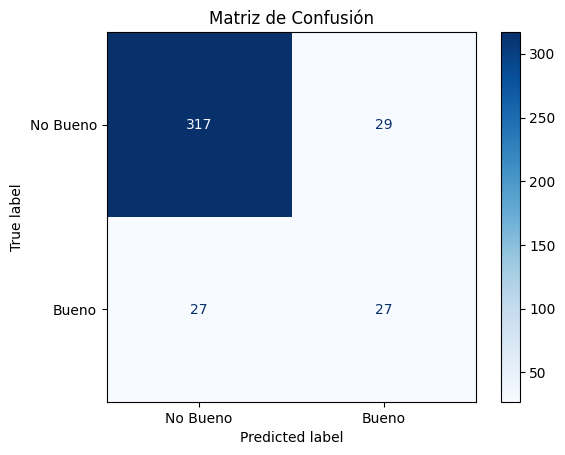

[[317  29]
 [ 27  27]]


In [61]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Bueno', 'Bueno'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

print(cm)

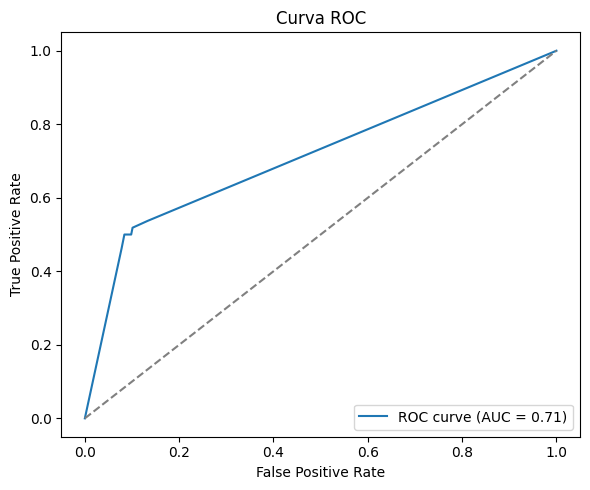

In [42]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Se puede observar que el modelo detecta muy bien los vinos “No Buenos”, que son la clase mayoritaria (92% de F1).Pero tiene dificultades para detectar los “Buenos”, que son mucho menos frecuentes: solo acierta en un 48% de los casos que predice como buenos.Esto era esperable dado el fuerte desbalance de clases

### 6.1. Mejoras del modelo

Se plantea inicialmente balancear las clases con `class_weight='balanced'` en DecisionTreeClassifier que Ajusta los pesos de las clases de forma inversamente proporcional a su frecuencia.

In [44]:
# Entrenamos un nuevo modelo con balanceo
dt_balanced = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

# Entrenamos con los datos de entrenamiento
dt_balanced.fit(X_train, y_train)

# Predicciones
y_pred_bal = dt_balanced.predict(X_test)
y_prob_bal = dt_balanced.predict_proba(X_test)[:, 1]

Se revisa el reporte

Reporte de clasificación (con class_weight='balanced'):
              precision    recall  f1-score   support

    No Bueno       0.94      0.88      0.91       346
       Bueno       0.45      0.63      0.52        54

    accuracy                           0.84       400
   macro avg       0.69      0.75      0.72       400
weighted avg       0.87      0.84      0.86       400



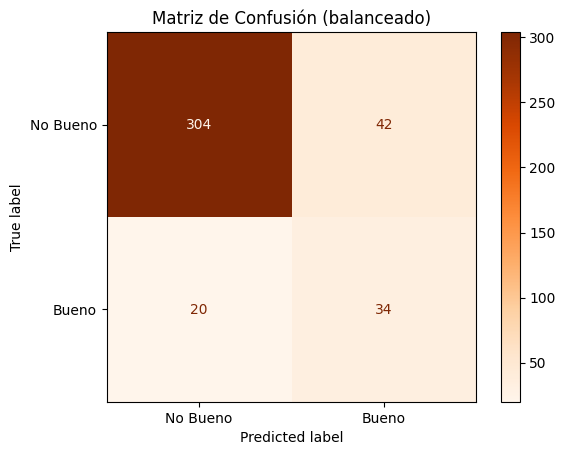

[[304  42]
 [ 20  34]]


In [48]:
print("Reporte de clasificación (con class_weight='balanced'):")
print(classification_report(y_test, y_pred_bal, target_names=['No Bueno', 'Bueno']))

# Matriz de confusión
cm_bal = confusion_matrix(y_test, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['No Bueno', 'Bueno'])
disp_bal.plot(cmap=plt.cm.Oranges)
plt.title('Matriz de Confusión (balanceado)')
plt.show()
print(cm_bal)

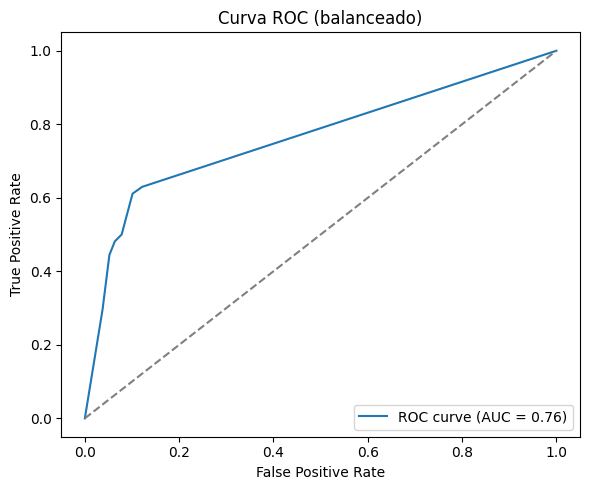

In [46]:
# Curva ROC
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)
roc_auc_bal = auc(fpr_bal, tpr_bal)

plt.figure(figsize=(6, 5))
plt.plot(fpr_bal, tpr_bal, label=f'ROC curve (AUC = {roc_auc_bal:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC (balanceado)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Al introducir el parámetro class_weight='balanced' en el árbol de decisión, se logró mejorar significativamente la detección de vinos de buena calidad (recall: 63% vs. 50%) sin comprometer drásticamente la precisión general del modelo. Esto es especialmente útil en contextos donde es más importante no pasar por alto vinos buenos, aún a costa de algunos falsos positivos. Además, la métrica AUC mejoró de 0.71 a 0.76, lo cual demuestra una mejor discriminación entre clases. Por lo tanto, el uso de balanceo en este caso es recomendable.

**SMOTE** : Finalmente para tratar de mejorar un poco mas el modelo SMOTE crea nuevas instancias sintéticas de la clase minoritaria interpolando entre ejemplos reales, esto solo se aplica al conjunto de entrenamiento

In [63]:


#SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#  nuevo árbol de decisión con los datos balanceados
dt_smote = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

dt_smote.fit(X_train_smote, y_train_smote)



DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [64]:
# Predicciones
y_pred_smote = dt_smote.predict(X_test)
y_prob_smote = dt_smote.predict_proba(X_test)[:, 1]



**Reporte de las métricas**

In [69]:
# Reporte de clasificación
print("Reporte de clasificación (SMOTE):")
print(classification_report(y_test, y_pred_smote, target_names=['No Bueno', 'Bueno']))

# Matriz de confusión
cm_smote = confusion_matrix(y_test, y_pred_smote)

print(cm_smote)

# Curva ROC
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

print(roc_auc_smote)

Reporte de clasificación (SMOTE):
              precision    recall  f1-score   support

    No Bueno       0.95      0.85      0.90       346
       Bueno       0.43      0.70      0.53        54

    accuracy                           0.83       400
   macro avg       0.69      0.78      0.71       400
weighted avg       0.88      0.83      0.85       400

[[295  51]
 [ 16  38]]
0.7880004281738386


Este método logró mejorar notablemente la sensibilidad del modelo (recall = 0.70) y obtuvo la mayor puntuación AUC (0.79), lo que indica una mejor capacidad del clasificador para distinguir entre vinos buenos y no buenos. Aunque se sacrificó ligeramente la precisión general (accuracy = 0.83), se logró un modelo más equilibrado y justo, ideal para escenarios donde identificar correctamente los vinos de alta calidad es una prioridad.

## 7. Visualización de los resultados

El modelo mejor ajustado fue el que se balancearon la clases con SMOTE, se visualiza la matriz de confusión y la curva ROC. Así mismo el arbol de decisiones final


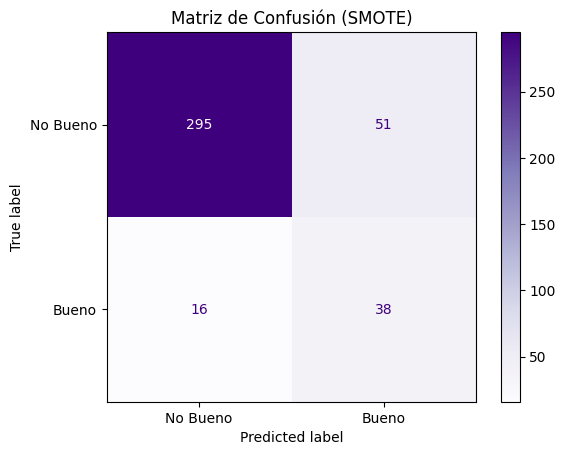

[[295  51]
 [ 16  38]]


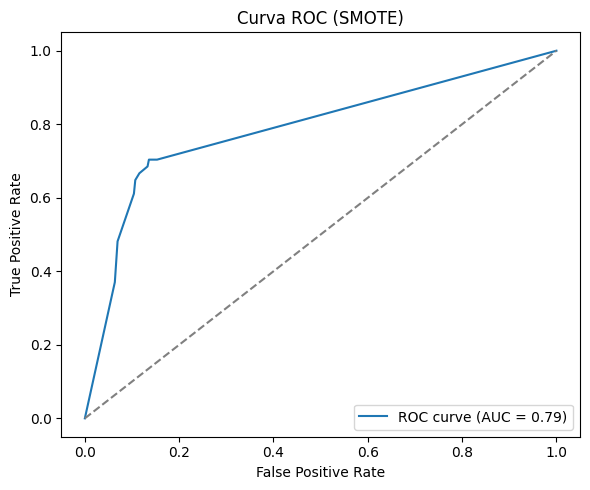

In [68]:
# Matriz de confusión
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Bueno', 'Bueno'])
disp.plot(cmap=plt.cm.Purples)
plt.title('Matriz de Confusión (SMOTE)')
plt.show()
print(cm_smote)

# Curva ROC
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

plt.figure(figsize=(6, 5))
plt.plot(fpr_smote, tpr_smote, label=f'ROC curve (AUC = {roc_auc_smote:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC (SMOTE)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Arbol de decisiones** Como el arbol es muy profundo se limitará la visualización a una versión mas simplificada con maximo 3 niveles, esto con el fin de entender mejor como está tomando las decisiones

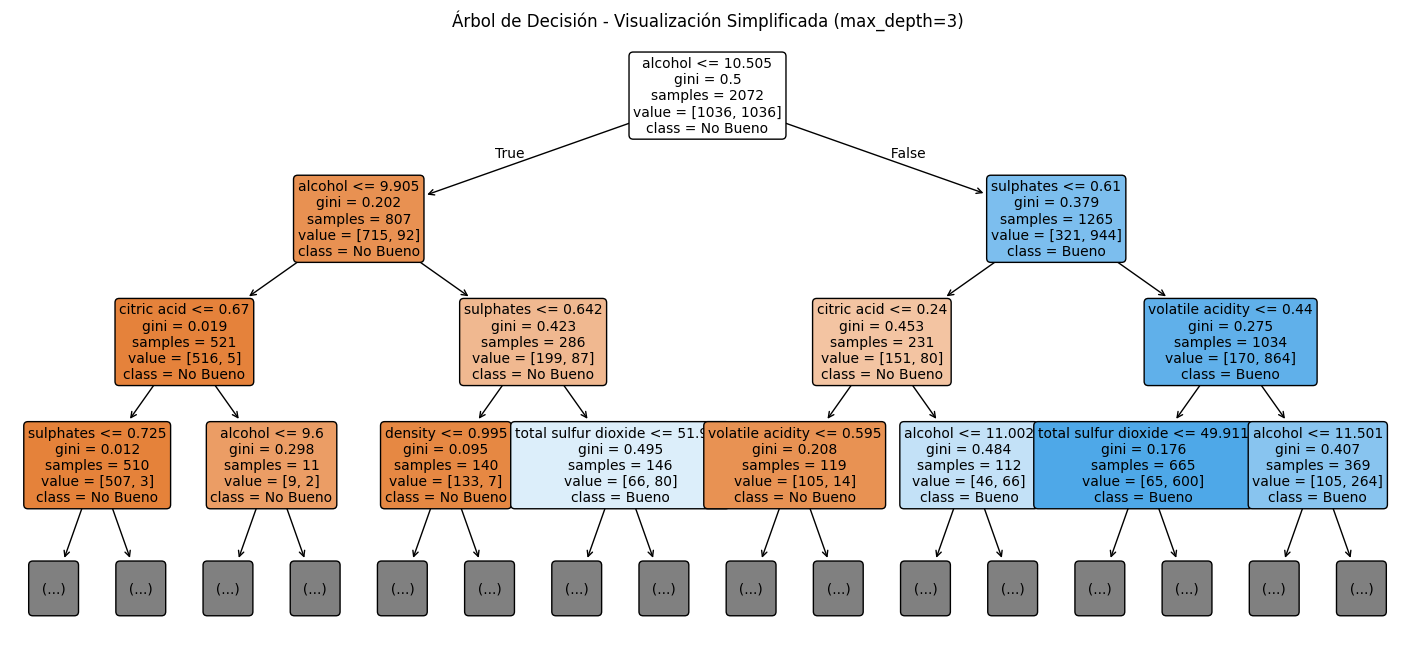

In [73]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt_smote,
    feature_names=X_train.columns,
    class_names=['No Bueno', 'Bueno'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # limita la visualización a 3 niveles
)
plt.title("Árbol de Decisión - Visualización Simplificada (max_depth=3)")
plt.show()

**Variables importantes** Se quiere conocer cuales son las variables mas importantes en el modelo, junto con su valor

<ipython-input-76-e8507e898039>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_sorted, y=importances_sorted.index, palette="coolwarm")


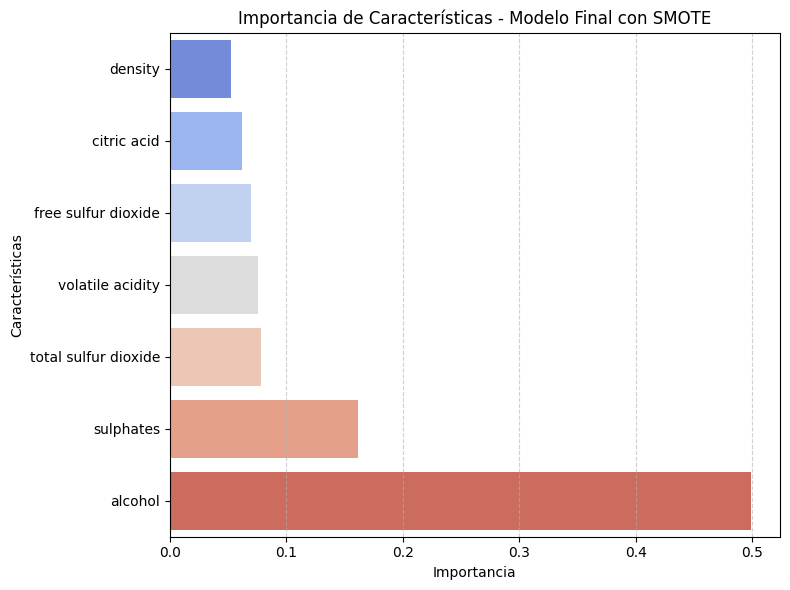

density                 0.052751
citric acid             0.062146
free sulfur dioxide     0.069881
volatile acidity        0.075877
total sulfur dioxide    0.078788
sulphates               0.161626
alcohol                 0.498931
dtype: float64


In [76]:
# Obtener las importancias del modelo
importances = pd.Series(dt_smote.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=True)

# Graficar
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_sorted, y=importances_sorted.index, palette="coolwarm")
plt.title("Importancia de Características - Modelo Final con SMOTE")
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(importances_sorted)

## 8. Analisis de Resultados:

1. Alcohol (Importancia: 0.4989)
El contenido de alcohol fue, con diferencia, la variable más importante del modelo. Esto tiene sentido, ya que el alcohol está estrechamente relacionado con la percepción de cuerpo, dulzura y calidez en el vino. En vinos tintos, un mayor nivel de alcohol suele estar asociado con una fermentación completa, uso de uvas más maduras y, en general, una mejor calidad percibida. Además, en la matriz de correlación, alcohol también mostró la correlación positiva más fuerte con la calidad (r ≈ 0.41).

2. Sulphates (Importancia: 0.1616)
Los sulfitos (expresados aquí como sulphates) son aditivos que ayudan a prevenir la oxidación y el crecimiento de bacterias. En pequeñas cantidades, pueden mejorar la estabilidad del vino, pero en exceso pueden afectar negativamente el sabor. Su alta importancia indica que el modelo ha encontrado una relación significativa entre niveles óptimos de sulfitos y vinos de mayor calidad.

3. Total Sulfur Dioxide (Importancia: 0.0788)
Este parámetro mide la suma de formas libres y ligadas de dióxido de azufre (SO₂). Aunque es necesario para conservar el vino, un contenido elevado puede producir olores desagradables y reducir la calidad percibida. En la matriz de correlación, mostró una correlación negativa con la calidad, lo cual también respalda esta conclusión.

4. Volatile Acidity (Importancia: 0.0759)
La acidez volátil está relacionada con la cantidad de ácido acético (vinagre) en el vino. Aunque una pequeña cantidad es aceptable, niveles altos indican defectos en el proceso de fermentación y deterioran fuertemente la calidad. Su importancia en el modelo refleja que valores más altos tienden a clasificarse como “No buenos”.

5. Free Sulfur Dioxide (Importancia: 0.0699)
El SO₂ libre es la fracción activa del total que protege contra microbios y oxidación. Si bien es importante para la estabilidad del vino, su efecto directo sobre la calidad sensorial no es tan claro, por lo que su menor importancia relativa frente al total sulfur dioxide es esperable.

**Reglas para un buen vino**

In [80]:

# Exportar las reglas del árbol como texto
tree_rules = export_text(dt_smote, feature_names=list(X_train.columns), max_depth=4, class_names=['No buen vino', 'Buen vino'])  # puedes ajustar el max_depth
print(tree_rules)

|--- alcohol <= 10.50
|   |--- alcohol <= 9.91
|   |   |--- citric acid <= 0.67
|   |   |   |--- sulphates <= 0.73
|   |   |   |   |--- sulphates <= 0.62
|   |   |   |   |   |--- class: No buen vino
|   |   |   |   |--- sulphates >  0.62
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- sulphates >  0.73
|   |   |   |   |--- sulphates <= 0.76
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- sulphates >  0.76
|   |   |   |   |   |--- class: No buen vino
|   |   |--- citric acid >  0.67
|   |   |   |--- alcohol <= 9.60
|   |   |   |   |--- class: No buen vino
|   |   |   |--- alcohol >  9.60
|   |   |   |   |--- class: Buen vino
|   |--- alcohol >  9.91
|   |   |--- sulphates <= 0.64
|   |   |   |--- density <= 0.99
|   |   |   |   |--- density <= 0.99
|   |   |   |   |   |--- class: No buen vino
|   |   |   |   |--- density >  0.99
|   |   |   |   |   |--- class: Buen vino
|   |   |   |--- density >  0.99
|   |   |   |   |--- citric acid <= 0

Estas reglas nos muestran que el nivel de alcohol es el atributo más decisivo, seguido por:

Sulphates (relacionados con la textura),

Citric acid (frescura),

Volatile acidity (relacionado con aromas) y

Sulfur dioxide (preservante).

